In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

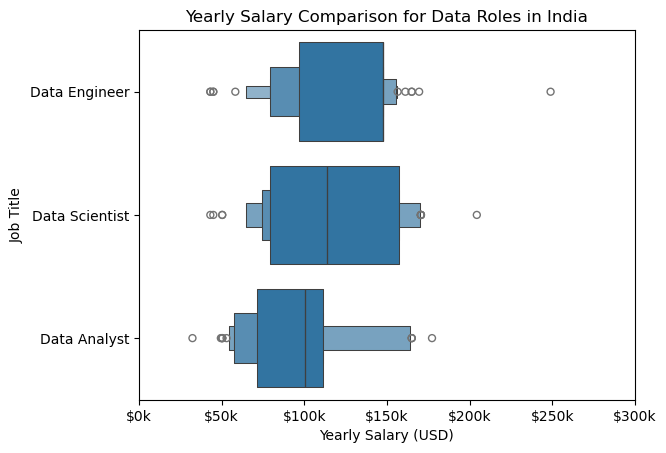

In [ ]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_ind = df[df['job_country'] == 'India'].dropna(subset=['salary_year_avg'])
df_job = df_ind[df_ind['job_title_short'].isin(job_titles)]


sns.boxenplot(data = df_job, y= 'job_title_short', x= 'salary_year_avg')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y/1000:.0f}k'))

plt.xlim(0, 300_000)
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Job Title')
plt.show()
